# Getting Started with Liveness Property Verification

This notebook, similar to the notebook for getting started with safety property verification, includes some API descriptions and examples doing verification with our tool (implemented in Java using Batfish).

In [1]:
# Runs the set up script and imports used classes
from verificationPythonSupport import LocationPropertyPair,LivenessQuery,Clause,Property
from verificationPythonSupport import trueAtLocation, trueProperty, falseAtLocation, falseProperty
from startup import runAndDisplay, runAndGet
%run startup.py

## Example One - Simple 3 Node Network

The image below describes the topology and route mpas for the network used for example one.

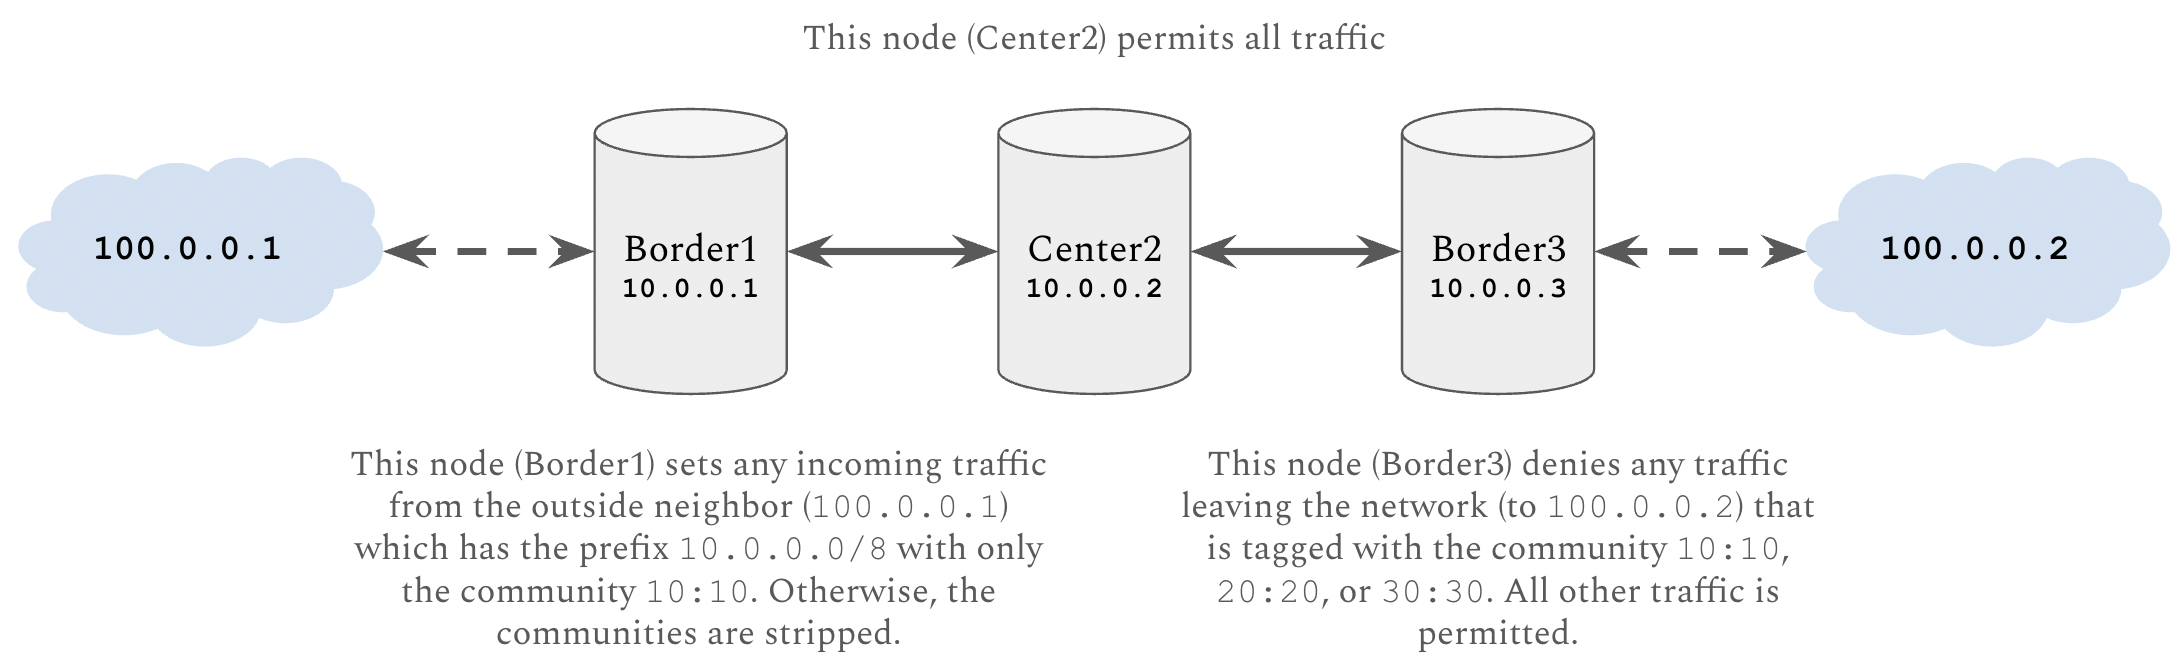

The code will show that there is no way for traffic with the prefix `10.0.0.0/8` to reach the target destination on the right (the outgoing edge `Border3 -> 100.0.0.2`). This is expected because this traffic (having prefix `10.0.0.0/8`) is always tagged with the community `10:10` when entering on the left, and any traffic with the community `10:10` is denied going out on the right.

Note - we do not consider the possible path of traffic from `100.0.0.2 -> Border3 -> 100.0.0.2` because paths where traffic is sent back over the edge it came from are not considered as this does not happen in BGP.

In [2]:
networkName = "exampleOne_network"
snapshotName = "exampleOne_snapshot"
snapshotPath = "liveness_snapshots/exampleOne"

# prefix = the traffic that our liveness query pertains to 
prefix = "10.0.0.0/8"
# target = the liveness property we care about, in this case it is just "true" 
# which is attempting to just show that traffic with this prefix will get to this location
target = trueAtLocation("10.0.0.3 -> 100.0.0.2")

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,False
1,Failed Path,{FALSE} 100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.2 [center2] 10.0.0.2 -> 10.0.0.3 [border3] 10.0.0.3 -> 100.0.0.2


In the previous result, the _Incomplete Path_ returned refers to one of the best effort paths we tried to see if "good traffic" could reach our intended destination. We'll show the user up to five of the shortests paths that we attempted in order to hopefully provide some insight as to where their "good traffic" might be getting stuck. In this example, there is only one possible route as the other route which comes from outside the network would require immediately going back over the edge it came from - so it is not considered.

In this case, the result `{FALSE} 100.0.0.1 -> 10.0.0.1 [bor...` can be interpretted as: at this point in the path, we concluded that there was no possible traffic which could be at this location (the location being the edge `100.0.0.1 -> 10.0.0.1`) which could reach our target location and satisfy the target property.

In the query below, instead of just checking that any route with the prefix `10.0.0.0/8` reaches the rightmost outgoing edge, we want that traffic to also the community `10:10`. Of course, this will also fail as this target condition implies the previously failing one; but, this one will fail sooner.

This is because as soon as taking one step from the target location (the outgoing edge `Border3 -> 100.0.0.2`) we know there is not route which can satisfy this because any route which has the community `10:10` is immediately denied. Thus, as soon as we get to the node, we know this path won't work.

So, when you have a "failing" path, you can look at where the inconsistency was detected. In both of these cases, our inference concluded that the was no possible traffic which could be at this location and successfully reach our target. Later in the notebook, we'll see an example where the path is deemed "bad" not because no traffic is possible but because the provided assumption does not meet the necessary condition.

In [3]:
networkName = "exampleOne_network"
snapshotName = "exampleOne_snapshot"
snapshotPath = "liveness_snapshots/exampleOne"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="10.0.0.3 -> 100.0.0.2",property=[Clause(communities=["10:10"])])

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,False
1,Failed Path,{FALSE} [border3] 10.0.0.3 -> 100.0.0.2


Below, you'll see if we just change the prefix that we care about, we'll be able to verify that it can reach the target location (with no detected inference). This of course is not that interesting on this simple network, but you can see an example of the path that this route announcement can successfully take through the network to reach the intended destination.

There are invariants associated with each step in the network that hold, allowing for this "good traffic" to reach the target destination. We are currently thinking about the best way to display this to the user (as in theory these paths could be long) - right now, we are just displaying the path.

In [4]:
networkName = "exampleOne_network"
snapshotName = "exampleOne_snapshot"
snapshotPath = "liveness_snapshots/exampleOne"

prefix = "12.0.0.0/8"
target = trueAtLocation("10.0.0.3 -> 100.0.0.2")

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,True
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.2 [center2] 10.0.0.2 -> 10.0.0.3 [border3] 10.0.0.3 -> 100.0.0.2


The below pieces of code deal with the same network except for on the export policy from `Border3 -> 100.0.0.2` the effect is negated -- if any community matches then the route is permitted, otherwise it is denied. And, on the incoming policy from `100.0.0.1 -> Border1` no communities are stripped.

First, we can now verify that if traffic comes into the network with the prefix `10.0.0.0/8`, then will be advertised over the edge leaving the network from the node `Border3`.

In [5]:
networkName = "exampleOnePermits_network"
snapshotName = "exampleOnePermits_snapshot"
snapshotPath = "liveness_snapshots/exampleOnePermits"

prefix = "10.0.0.0/8"
target = trueAtLocation("10.0.0.3 -> 100.0.0.2")

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,True
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.2 [center2] 10.0.0.2 -> 10.0.0.3 [border3] 10.0.0.3 -> 100.0.0.2


Next, we can prove that traffic will reach the outgoing edge with the prefix `10.0.0.0/8` and the community `10:10`. 

In [6]:
networkName = "exampleOnePermits_network"
snapshotName = "exampleOnePermits_snapshot"
snapshotPath = "liveness_snapshots/exampleOnePermits"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="10.0.0.3 -> 100.0.0.2",property=[Clause(communities=["10:10"])])
# assumption = included assumption to support the verification (added to the query below)
assumption = LocationPropertyPair(location="100.0.0.2 -> border3",property=[Clause(prefixes=["!10.0.0.0/8"])])

query = LivenessQuery(prefix=prefix, target=target, assumptions=[assumption])

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,True
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.2 [center2] 10.0.0.2 -> 10.0.0.3 [border3] 10.0.0.3 -> 100.0.0.2


Notice, we need to include an assumption that "bad traffic" is not coming in from other ingress node. If this assumption is not there, then our inference detects that it is possible for routes with the prefix `10.0.0.0/8` and one of the two permitted communities (not `10:10`) to reach the location and potentially interfere. An example of running this query without the assumption is right below.

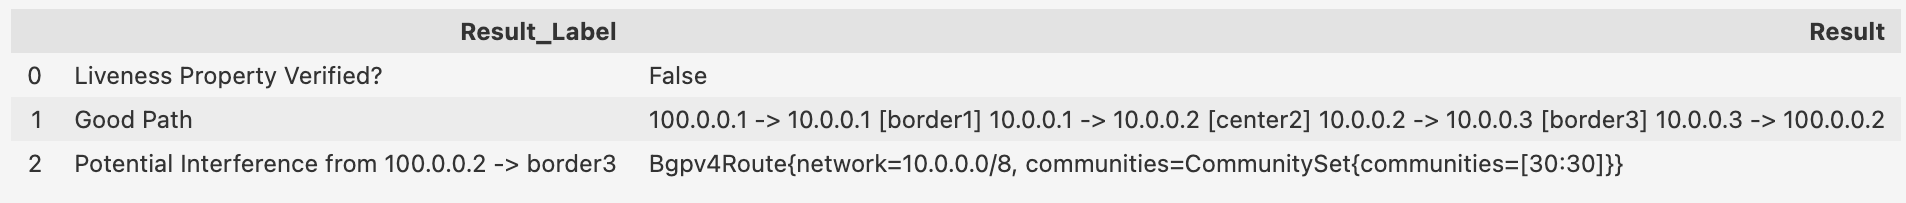

This is currently a limitation of invariant inference which maintains soundness but allows for false negatives. In this case, the way to avoid that is place an assumption coming on that edge which will prevent counterexamples from arising. It might be a good idea to include this automatically in the tool to attempt to limit false negatives, but for now it must be made explicit by the user.

Specifically, this examples indicates that, while there is a "good path" (a way for the liveness condition to be satisfied), there is a potentially interferring route which might come in on the edge `100.0.0.2 -> Border3` that has the prefix we care about but does not satisfy the property we care about (that is, it does not the community `10:10`). In practice, this won't happen because even if this traffic comes in it will never be immediately sent back over (and further, it will only ever move in the opposite direction in this network because there is only a single path). Thus, we can safetly make this assumption.

## Example Two - Simple Diamond Network

The image below describes the example reflect by the network in example two.

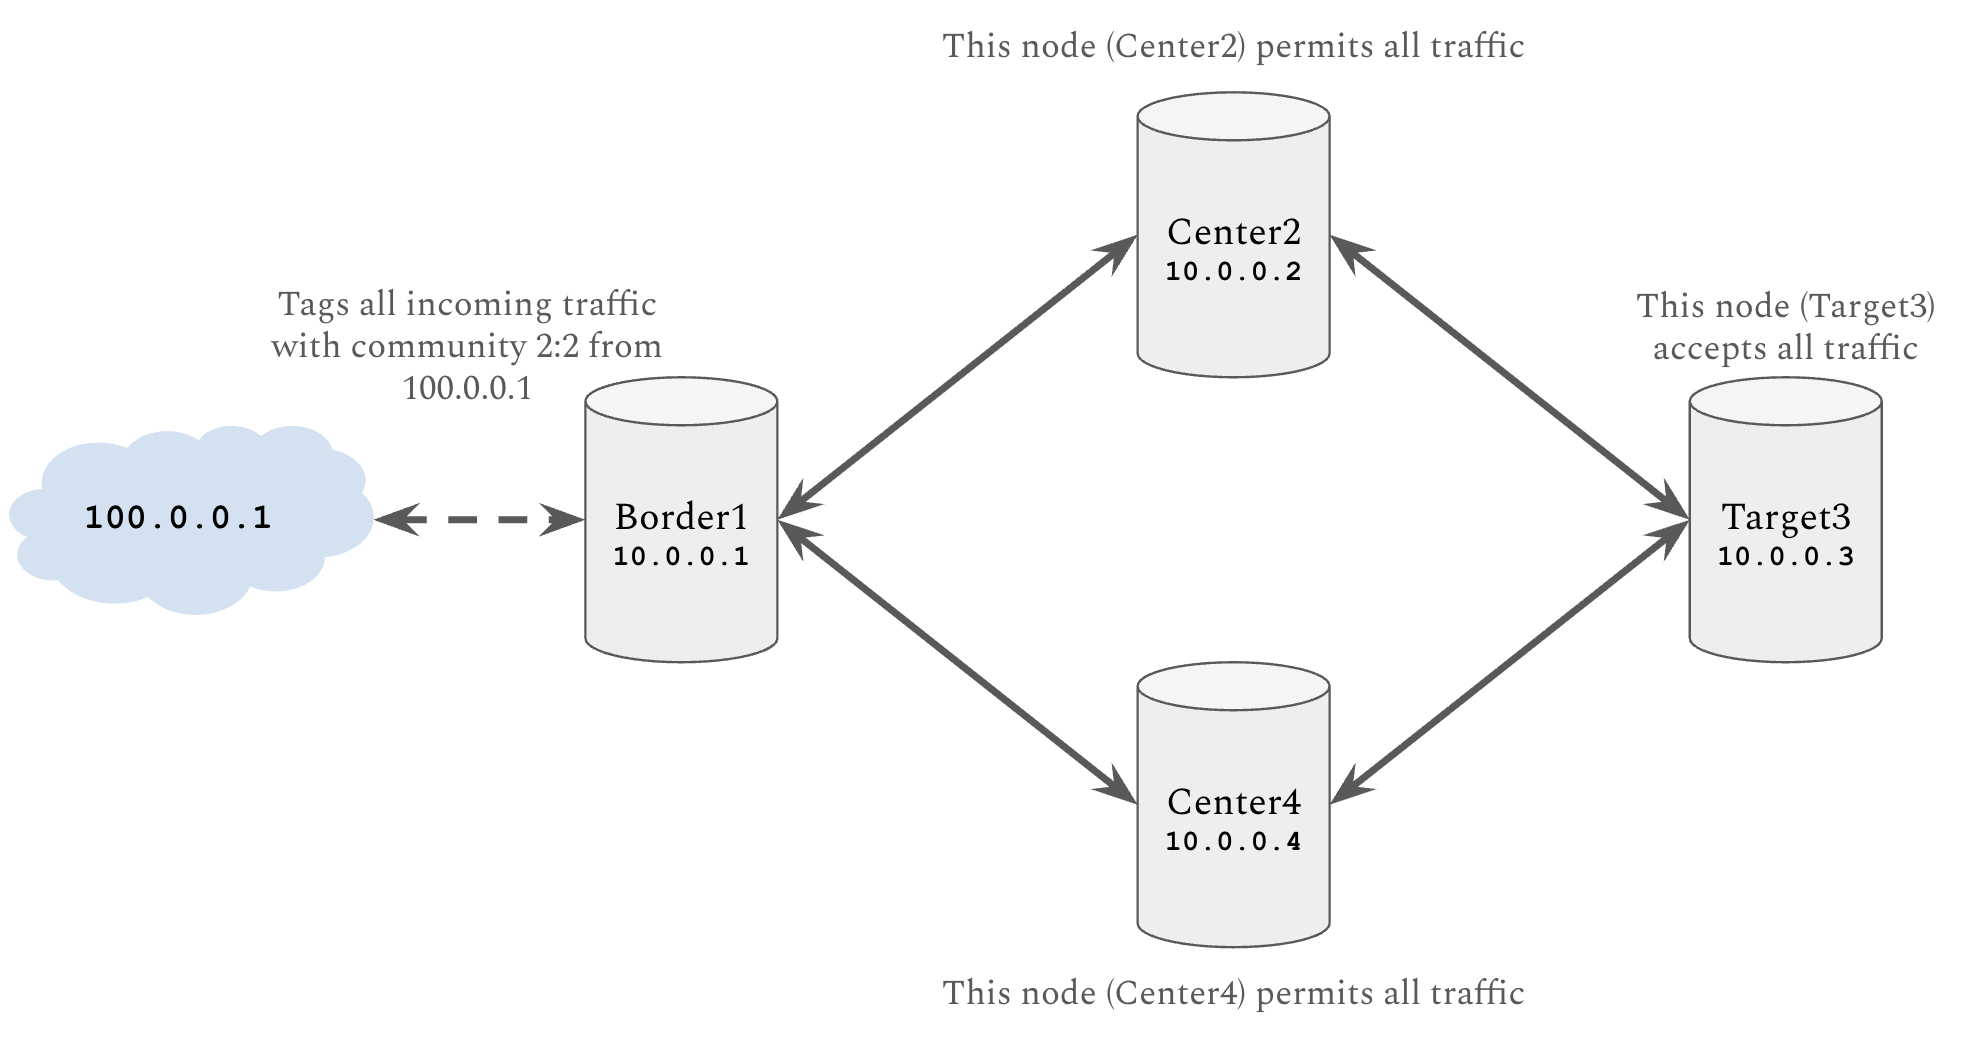

In [7]:
networkName = "exampleTwo_network"
snapshotName = "exampleTwo_snapshot"
snapshotPath = "liveness_snapshots/exampleTwo"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target3",property=[Clause(communities=["2:2"])])

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,True
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.2 [center2] 10.0.0.2 -> 10.0.0.3 [target3]


In [8]:
networkName = "exampleTwoV1_network"
snapshotName = "exampleTwoV1_snapshot"
snapshotPath = "liveness_snapshots/exampleTwoV1"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target3",property=[Clause(communities=["2:2"])])

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,False
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [center4] 10.0.0.4 -> 10.0.0.3 [target3]
2,Potential Interference from 100.0.0.1 -> border1,Bgpv4Route{network=10.0.0.0/8}


In [9]:
networkName = "exampleTwoV2_network"
snapshotName = "exampleTwoV2_snapshot"
snapshotPath = "liveness_snapshots/exampleTwoV2"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target3",property=[Clause(communities=["2:2"])])

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,True
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [center4] 10.0.0.4 -> 10.0.0.3 [target3]


## Example Two - Simple Modified Diamond Network

The image below describes the example reflect by the network in example two.

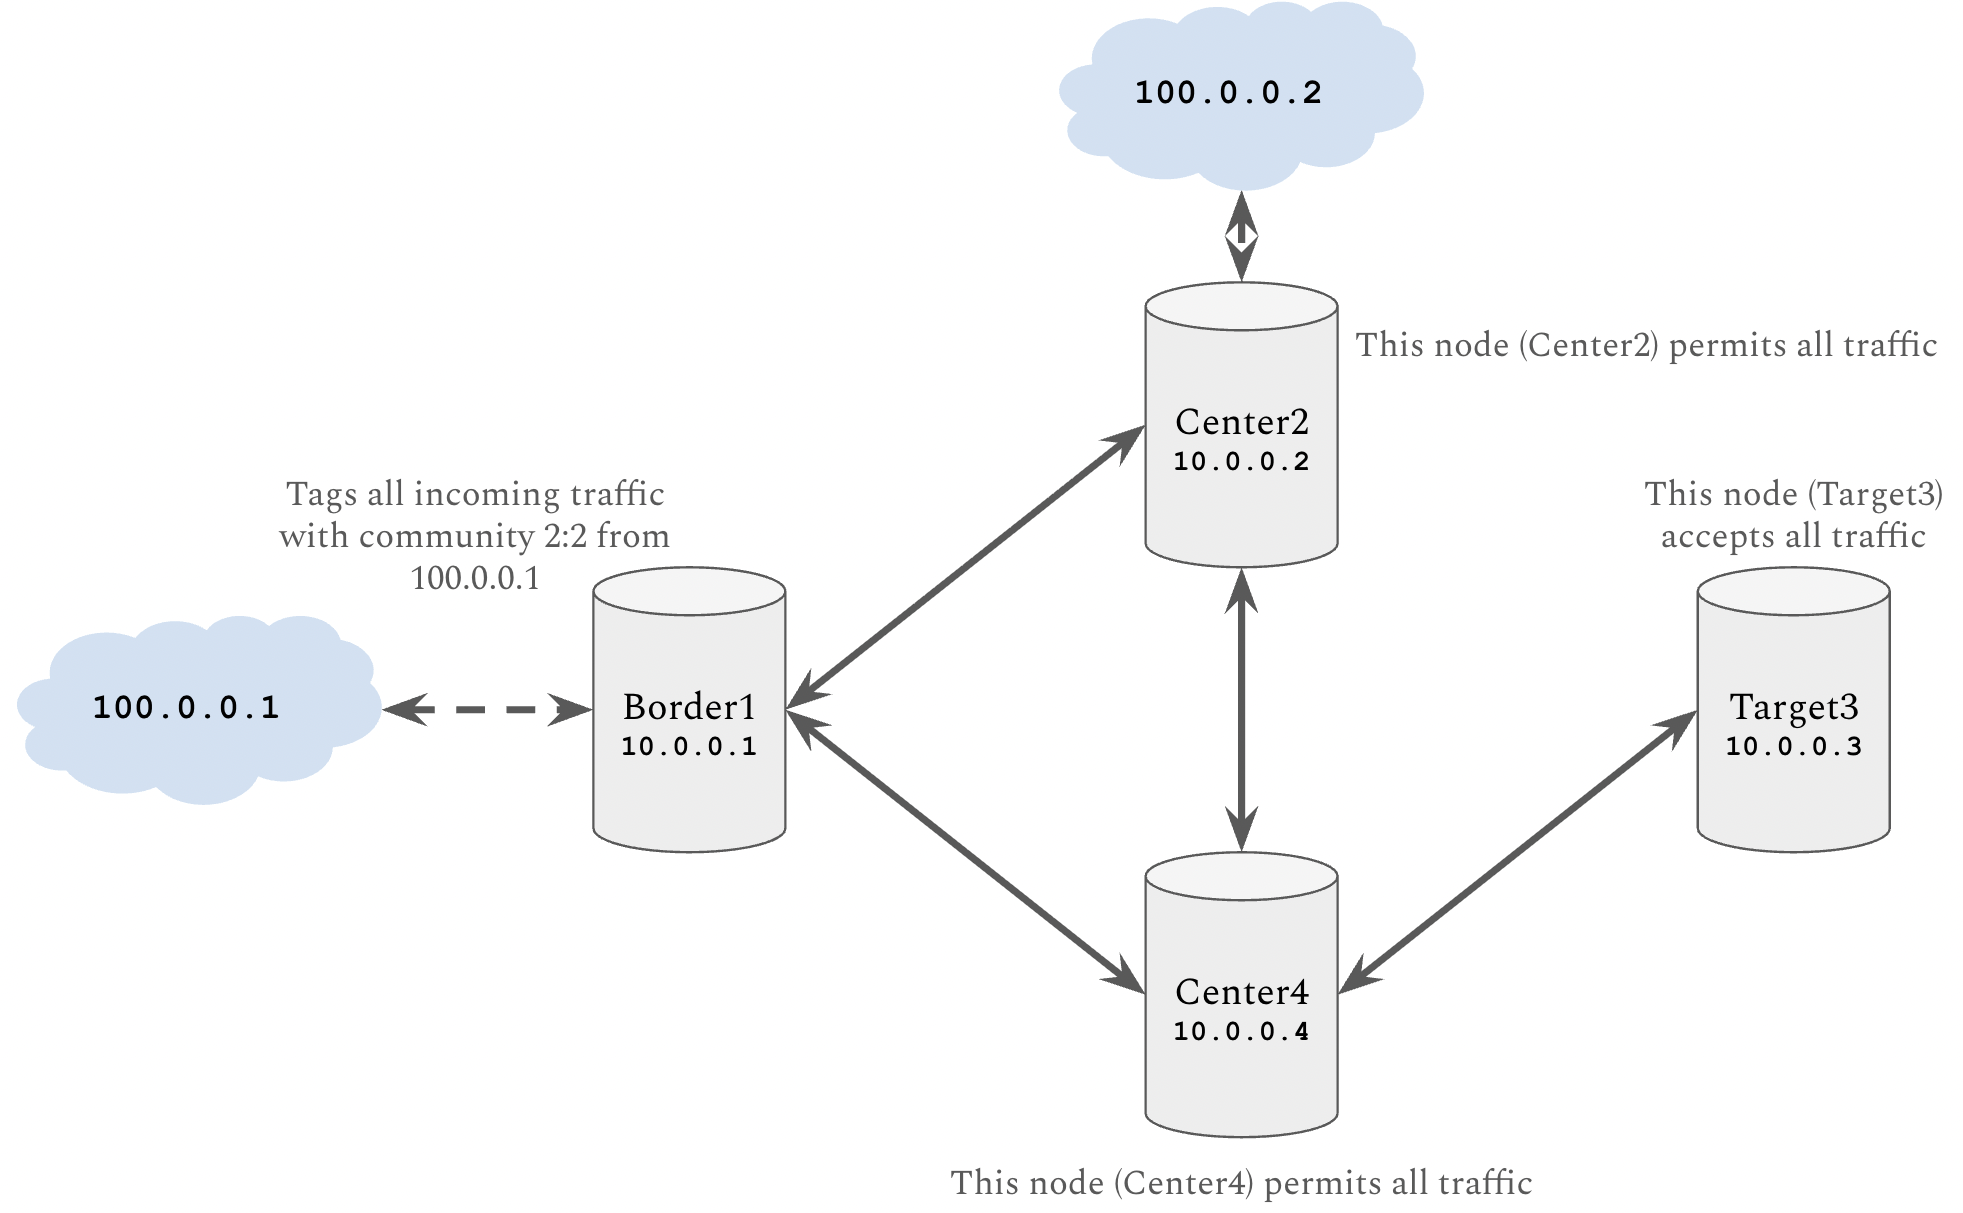

The test below runs the network above except for the fact that `Center2` has no outside connection - so the edge `10.0.0.2 <-> 100.0.0.2` does not exist. This network still satisfies the property that some good path exists that allows routes with prefix `10.0.0.0/8` to reach the node `Target3` with the community `2:2`.

In [10]:
networkName = "exampleThree_network"
snapshotName = "exampleThree_snapshot"
snapshotPath = "liveness_snapshots/exampleThree"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target3",property=[Clause(communities=["2:2"])])

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,True
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [center4] 10.0.0.4 -> 10.0.0.3 [target3]


The example below matches the image above, where there is potential interference from the edge `100.0.0.2 -> 10.0.0.2` coming into the network.

In [11]:
networkName = "exampleThreeV1_network"
snapshotName = "exampleThreeV1_snapshot"
snapshotPath = "liveness_snapshots/exampleThreeV1"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target3",property=[Clause(communities=["2:2"])])

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,False
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [center4] 10.0.0.4 -> 10.0.0.3 [target3]
2,Potential Interference from 100.0.0.2 -> center2,Bgpv4Route{network=10.0.0.0/8}


## Example Three - Triangle Network with Center Node

The image belows describes the example reflected in our third example (in the folder `exampleFour`).

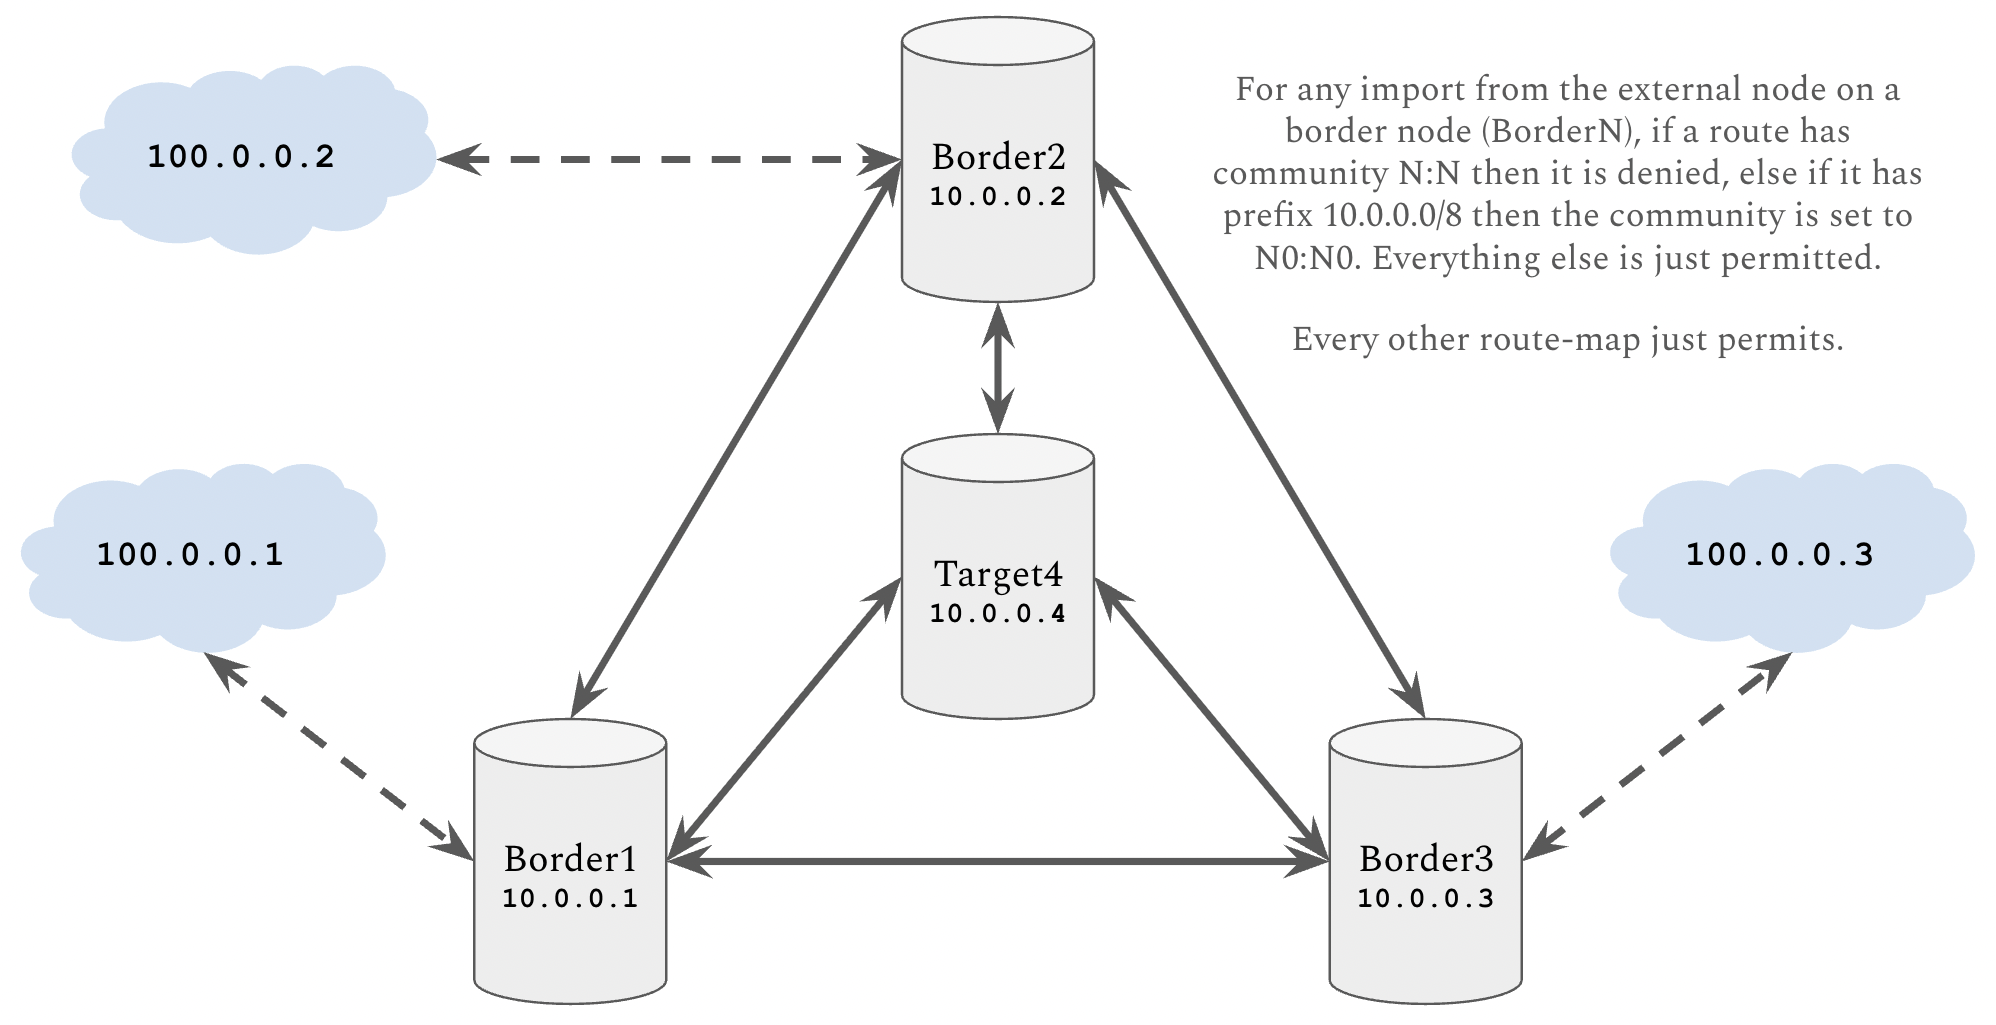

The liveness property we want to verify is that routes with prefix `10.0.0.0/8` reach the center node `Target4` with the community `10:10`.

In [12]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "liveness_snapshots/exampleFour"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target4",property=[Clause(communities=["10:10"])])

query = LivenessQuery(prefix=prefix, target=target)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,False
1,Failed Path,{FALSE} 100.0.0.2 -> 10.0.0.2 [border2] 10.0.0.2 -> 10.0.0.4 [target4]
2,Failed Path,{FALSE} 100.0.0.3 -> 10.0.0.3 [border3] 10.0.0.3 -> 10.0.0.4 [target4]
3,Failed Path,"Inferred Invariant: !comm(1:1),prefix(10.0.0.0/8) Bgpv4Route{network=10.0.0.0/8, communities=CommunitySet{communities=[1:1]}} 100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]"
4,Failed Path,{FALSE} 100.0.0.2 -> 10.0.0.2 [border2] 10.0.0.2 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]
5,Failed Path,{FALSE} 100.0.0.3 -> 10.0.0.3 [border3] 10.0.0.3 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]


In this case, this verification fails because if routes with the community `1:1` and prefix `10.0.0.0/8` come into node `Border1`, then this route gets denied. Thus, we need to either change our order in the config, or do what is done below (include an assumption that incoming traffic doesn't have the community `1:1` and prefix `10.0.0.0/8`).

In [13]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "liveness_snapshots/exampleFour"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target4",property=[Clause(communities=["10:10"])])
# stating that communities = !1:1 is sufficient, but this assumption is more exact
assumption = LocationPropertyPair(location="100.0.0.1 -> border1",property=[Clause(communities=["!1:1"]),Clause(prefixes=["!10.0.0.0/8"])])

query = LivenessQuery(prefix=prefix, target=target,assumptions=[assumption])

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,False
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]
2,Potential Interference from 100.0.0.2 -> border2,Bgpv4Route{network=10.0.0.0/8}
3,Potential Interference from 100.0.0.3 -> border3,Bgpv4Route{network=10.0.0.0/8}


This will show us there is in fact a "good path" which will satisfy our liveness property. However, there is possible interference coming in on nodes `Border2` and `Border3`. Specifically, if the prefix we care about enters into these nodes, then it will not get tagged with the desired community.

The following two cells do not resolve this issue, instead they show case how you can set the **ingress** location to specify where you want the traffic to originate. That is, any "good path" considered will start at the provided ingress location. You'll notice that possible interference will still be detected because the ingress node does not imply that is the _only_ place traffic can come but rather where we want to see if traffic can come from and reach the target destination.

In [14]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "liveness_snapshots/exampleFour"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target4",property=[Clause(communities=["10:10"])])
default = Property(clauses=[Clause(communities=["!1:1"])])
ingress = "100.0.0.1 -> border1"

query = LivenessQuery(prefix=prefix, target=target,default=default,ingress=ingress)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,False
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]
2,Potential Interference from 100.0.0.2 -> border2,Bgpv4Route{network=10.0.0.0/8}
3,Potential Interference from 100.0.0.3 -> border3,Bgpv4Route{network=10.0.0.0/8}


In [15]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "liveness_snapshots/exampleFour"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target4",property=[Clause(communities=["10:10"])])
default = Property(clauses=[Clause(communities=["!1:1"])])
ingress = "100.0.0.2 -> border2"

query = LivenessQuery(prefix=prefix, target=target,default=default,ingress=ingress)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,False
1,Failed Path,{FALSE} 100.0.0.2 -> 10.0.0.2 [border2] 10.0.0.2 -> 10.0.0.4 [target4]
2,Failed Path,{FALSE} 100.0.0.2 -> 10.0.0.2 [border2] 10.0.0.2 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]
3,Failed Path,{FALSE} 100.0.0.2 -> 10.0.0.2 [border2] 10.0.0.2 -> 10.0.0.3 [border3] 10.0.0.3 -> 10.0.0.4 [target4]
4,Failed Path,{FALSE} 100.0.0.2 -> 10.0.0.2 [border2] 10.0.0.2 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.3 [border3] 10.0.0.3 -> 10.0.0.4 [target4]
5,Failed Path,{FALSE} 100.0.0.2 -> 10.0.0.2 [border2] 10.0.0.2 -> 10.0.0.3 [border3] 10.0.0.3 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]


In the following cell, we add the default assumption of all routes having the communities `2:2` and `3:3`. This will ensure traffic coming into nodes `Border2` and `Border3` from the outside are denied, eliminating the possible interference.

In [16]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "liveness_snapshots/exampleFour"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target4",property=[Clause(communities=["10:10"])])
default = Property(clauses=[Clause(communities=["2:2","3:3"])])
assumption = LocationPropertyPair(location="100.0.0.1 -> border1",property=[Clause(communities=["!1:1"])])

query = LivenessQuery(prefix=prefix, target=target, assumptions=[assumption],default=default)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,True
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]


Next, we'll tweak the configs so that between the border nodes communities are stripped. This will introduce possible interference because the target community might get stripped if the route passes through another border node after coming in through `Border1`. Even in the cell below, if we assume not traffic comes in through any edge besides `100.0.0.1 -> border1`, this traffic might still pass through the other border nodes and interfere at the target.

In [17]:
networkName = "exampleFourV1_network"
snapshotName = "exampleFourV1_snapshot"
snapshotPath = "liveness_snapshots/exampleFourV1"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target4",property=[Clause(communities=["10:10"])])
default = falseProperty()
assumption = LocationPropertyPair(location="100.0.0.1 -> border1",property=[Clause(communities=["!1:1"])])

query = LivenessQuery(prefix=prefix, target=target, assumptions=[assumption],default=default)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,False
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]
2,Potential Interference from 100.0.0.1 -> border1,Bgpv4Route{network=10.0.0.0/8}


Finally, we can tweak the network one more time so that `Border1` does not accept any routes from the other border nodes. We also make sure the nodes `Border2` and `Border3` don't strip communities. These modifications allow use to verify the property under the assumptions below.

This last example was mainly included to illustrate how the `ingress`, `assumptions`, and `default` fields can be used.

In [18]:
networkName = "exampleFourV2_network"
snapshotName = "exampleFourV2_snapshot"
snapshotPath = "liveness_snapshots/exampleFourV2"

prefix = "10.0.0.0/8"
target = LocationPropertyPair(location="target4",property=[Clause(communities=["10:10"])])
default = falseProperty()
assumption = LocationPropertyPair(location="100.0.0.1 -> border1",property=[Clause(communities=["!1:1"])])

query = LivenessQuery(prefix=prefix, target=target, assumptions=[assumption],default=default)

runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Result_Label,Result
0,Liveness Property Verified?,True
1,Good Path,100.0.0.1 -> 10.0.0.1 [border1] 10.0.0.1 -> 10.0.0.4 [target4]
